In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
mpl.rcParams.update({
    'font.family': 'serif',         # Use generic serif font family
    'font.serif': ['cmr10'],
    'font.sans-serif': ['cmss10'],
    'font.monospace': ['cmtt10'],
    'axes.formatter.use_mathtext': True,
    'mathtext.fontset': 'cm',       # Use matplotlib's internal Computer Modern fonts for math
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})
plt.rcParams['text.usetex'] = True
from matplotlib.patches import Patch

from pathlib import Path
from itertools import cycle

import seaborn as sns

from src.neural_network import TimeshiftsNN

In [5]:
training_timeshifts = np.load('timeshifts_20k_q_3.0.npy')
training_param_array = np.load('params_20k_q_3.0.npy')

print(training_param_array.shape)
print(training_timeshifts.shape)

param_names = [r'$q$', r'$\Lambda_1$', r'$\Lambda_2$', r'$\chi_1$', r'$\chi_2$']

(20000, 5)
(20000,)


In [ ]:
# Load RFF surrogate and compute predictions
import sys
project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

In [ ]:
N_train = len(training_timeshifts) // 10 * 9
pkl_path = project_root / "timeshifts_rff_surrogate.pkl"
rff_model = TimeshiftsNN.load_model(str(pkl_path))
rff_prediction = rff_model.predict(training_param_array[N_train:])
rff_residuals = training_timeshifts[N_train:] - rff_prediction
rff_residuals_ms = rff_residuals * 1e3

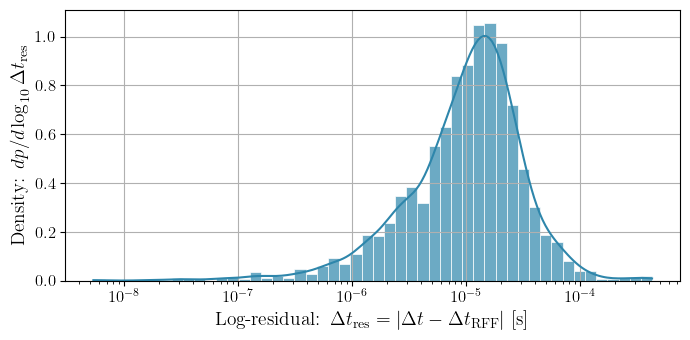

In [ ]:
prediction = rff_prediction
residuals = training_timeshifts[N_train:] - prediction
abs_residuals = np.abs(residuals)

fig, ax = plt.subplots(figsize=(7, 3.5))
# Density instead of count
sns.histplot(
    abs_residuals,
    bins=50,
    kde=True,
    stat='density',      
    color="#2E86AB",
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    ax=ax,
    log_scale=True,
)

ax.set_xlabel(r'Log-residual: $\Delta t_{\mathrm{res}} = |\Delta t - \Delta t_{\mathrm{RFF}}|$ [s]')
ax.set_ylabel(r'Density: $dp/d \log_{10}\Delta t_{\mathrm{res}}$')
ax.grid(True)   

plt.tight_layout()
plt.savefig("timeshift_residuals_hist.png", bbox_inches='tight')
plt.savefig("timeshift_residuals_hist.pdf", bbox_inches='tight')
plt.show()

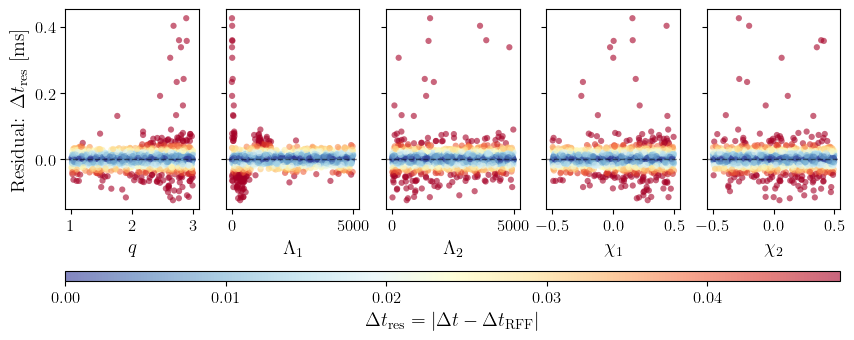

In [16]:
# Parameter distribution as residuals (RFF surrogate)
fig, axes = plt.subplots(1, 5, figsize=(10, 4), sharey=True)

for i, ax in enumerate(axes):
    # Color by absolute residual
    scatter = ax.scatter(
        training_param_array[N_train:, i],
        rff_residuals_ms,
        c=np.abs(rff_residuals_ms),
        cmap='RdYlBu_r',
        s=20,
        alpha=0.6,
        edgecolors='none',
        vmin=0,
        vmax=np.percentile(np.abs(rff_residuals_ms), 95),
    )
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel(param_names[i])

axes[0].set_ylabel(r'Residual: $\Delta t_{\mathrm{res}}$ [ms]')

# Shared colorbar
# Horizontal colorbar below plots
cbar = fig.colorbar(
    scatter, 
    ax=axes, 
    orientation='horizontal',
    pad=0.2,        # Increase padding to move it below
    shrink=1.0,      # Make it shorter (fraction of figure width)
    aspect=80,       # Aspect ratio (length/height)
)
cbar.set_label(r'$\Delta t_{\mathrm{res}} = |\Delta t - \Delta t_{\mathrm{RFF}}|$')

# plt.tight_layout()
plt.savefig('timeshifts_rff_residuals_vs_params.png', bbox_inches='tight')
plt.savefig('timeshifts_rff_residuals_vs_params.pdf', bbox_inches='tight')
plt.show()